In [5]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
import albumentations as A
from albumentations.pytorch import ToTensorV2
import timm

# Thư viện Grad-CAM
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# Cấu hình thiết bị
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Sử dụng thiết bị: {device}")

# Danh sách 14 bệnh lý
TARGET_CLASSES = [
    'Aortic enlargement', 'Atelectasis', 'Calcification', 'Cardiomegaly',
    'Consolidation', 'ILD', 'Infiltration', 'Lung Opacity', 'Nodule/Mass',
    'Other lesion', 'Pleural effusion', 'Pleural thickening', 'Pneumothorax',
    'Pulmonary fibrosis'
]

# Đường dẫn
IMG_DIR = "../data/processed/images_test_512" # Thư mục chứa ảnh test
CKPT_BCE = "../outputs/checkpoints/best_bce_seed42.pth"
CKPT_IMPROVED = "../outputs/checkpoints/best_asl_a2_seed42.pth" # Chuyển sang dùng ASL

Sử dụng thiết bị: cuda


In [2]:
def clean_state_dict(state_dict):
    """Xóa tiền tố 'module.' nếu model được train bằng DataParallel"""
    return {k.replace("module.", "") if k.startswith("module.") else k: v for k, v in state_dict.items()}

def load_model(checkpoint_path):
    """Khởi tạo và load trọng số cho DenseNet201"""
    model = timm.create_model('densenet201', pretrained=False, num_classes=14)
    state_dict = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(clean_state_dict(state_dict))
    model = model.to(device)
    model.eval()
    return model

def load_and_preprocess_image(img_path):
    """Đọc ảnh, trả về tensor cho Model và ảnh float [0,1] cho Visualization"""
    # Đọc ảnh gốc
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # 1. Pipeline cho ảnh vẽ Grad-CAM (Chỉ resize, scale về 0-1)
    transform_vis = A.Compose([A.Resize(512, 512)])
    img_vis = transform_vis(image=img)['image']
    img_vis_float = np.float32(img_vis) / 255.0 # Chuẩn hóa về [0, 1] để vẽ
    
    # 2. Pipeline cho Tensor đi vào Model (Resize + Normalize ImageNet)
    transform_tensor = A.Compose([
        A.Resize(512, 512),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225), max_pixel_value=255.0),
        ToTensorV2()
    ])
    input_tensor = transform_tensor(image=img)['image'].unsqueeze(0).to(device)
    
    return input_tensor, img_vis_float

In [7]:
def compare_gradcam_asl(img_path, target_class_idx):
    class_name = TARGET_CLASSES[target_class_idx]
    print(f"Đang vẽ Grad-CAM cho bệnh lý: {class_name}")
    
    # Load 2 Models
    model_bce = load_model(CKPT_BCE)
    model_improved = load_model(CKPT_IMPROVED)
    
    # Lấy layer cuối cùng trích xuất đặc trưng (của DenseNet201)
    target_layers_bce = [model_bce.features.norm5]
    target_layers_improved = [model_improved.features.norm5]
    
    # Chuẩn bị ảnh
    input_tensor, img_vis = load_and_preprocess_image(img_path)
    
    # Khởi tạo Grad-CAM
    cam_bce = GradCAM(model=model_bce, target_layers=target_layers_bce)
    cam_improved = GradCAM(model=model_improved, target_layers=target_layers_improved)
    
    # Chỉ định Class cần "nhìn"
    targets = [ClassifierOutputTarget(target_class_idx)]
    
    # Sinh Heatmap
    grayscale_cam_bce = cam_bce(input_tensor=input_tensor, targets=targets)[0, :]
    grayscale_cam_improved = cam_improved(input_tensor=input_tensor, targets=targets)[0, :]
    
    # Đè Heatmap lên ảnh gốc
    visualization_bce = show_cam_on_image(img_vis, grayscale_cam_bce, use_rgb=True)
    visualization_improved = show_cam_on_image(img_vis, grayscale_cam_improved, use_rgb=True)
    
    # Vẽ đồ thị so sánh
    fig, axes = plt.subplots(1, 3, figsize=(20, 7))
    
    axes[0].imshow(img_vis)
    axes[0].set_title("Ảnh gốc (Original CXR)", fontsize=16)
    axes[0].axis('off')
    
    axes[1].imshow(visualization_bce)
    axes[1].set_title(f"Baseline (BCE Loss)\nClass: {class_name}", fontsize=16, color='red')
    axes[1].axis('off')
    
    axes[2].imshow(visualization_improved)
    # SỬA TIÊU ĐỀ Ở ĐÂY
    axes[2].set_title(f"Improved (ASL)\nClass: {class_name}", fontsize=16, color='green')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

Đang vẽ Grad-CAM cho bệnh lý: Nodule/Mass


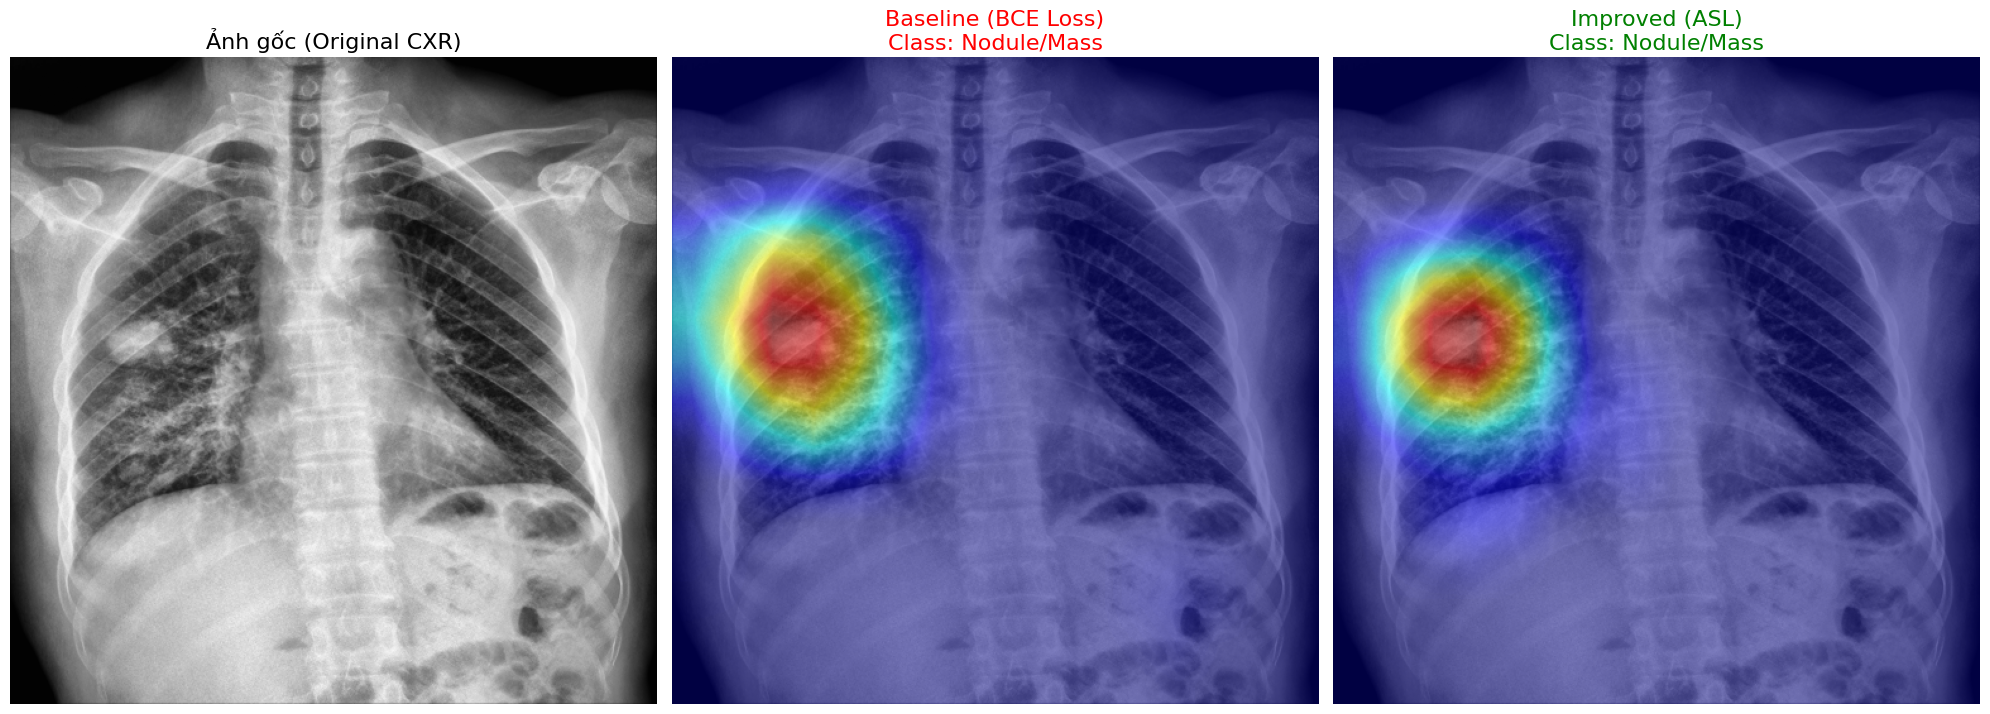

In [8]:
sample_image_name = "665c4a6d2693dc0286d65ab479c9b169.png"
sample_img_path = os.path.join(IMG_DIR, sample_image_name)

class_idx_to_visualize = 8 # Nodule/Mass

compare_gradcam_asl(sample_img_path, class_idx_to_visualize)